# Assignment 3: K-Nearest Neighbors (KNN) Classification
## Dataset: Bank Customer Churn (Churn_Modelling.csv)

Innovation Included:
- Feature Scaling Comparison
- Hyperparameter Tuning (K selection)
- Accuracy vs K Plot
- Confusion Matrix & Classification Report


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Without Scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
y_pred_no = knn_no_scale.predict(X_test)
print('Accuracy without scaling:', accuracy_score(y_test, y_pred_no))

Accuracy without scaling: 0.764


In [4]:
# With Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
print('Accuracy with scaling:', accuracy_score(y_test, y_pred_scaled))

Accuracy with scaling: 0.83


In [5]:
# Hyperparameter Tuning
accuracies = []
k_values = range(1,21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_values[np.argmax(accuracies)]
print('Best K:', best_k)

Best K: 19


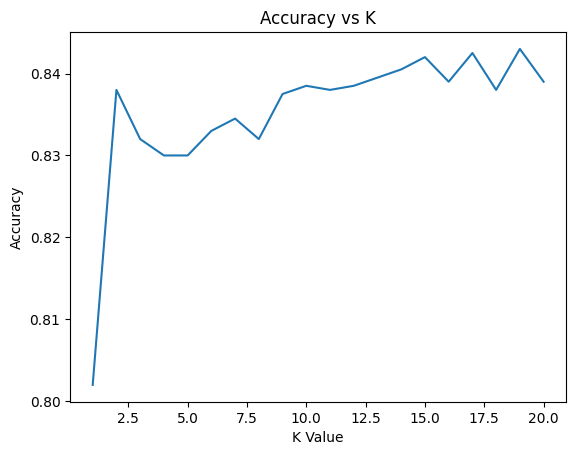

In [6]:
plt.figure()
plt.plot(k_values, accuracies)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K')
plt.show()

In [7]:
# Final Model
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_final = final_model.predict(X_test_scaled)

print('Final Accuracy:', accuracy_score(y_test, y_final))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_final))
print('\nClassification Report:\n', classification_report(y_test, y_final))

Final Accuracy: 0.843

Confusion Matrix:
 [[1559   48]
 [ 266  127]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91      1607
           1       0.73      0.32      0.45       393

    accuracy                           0.84      2000
   macro avg       0.79      0.65      0.68      2000
weighted avg       0.83      0.84      0.82      2000

